In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("default")
sns.set_style("whitegrid")

In [27]:
from pathlib import Path

data_path = (
    Path.cwd().parent
    / "data"
    / "cleaned"
    / "Telco-Customer-Churn-Cleaned.csv"
)

df = pd.read_csv(data_path)

df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [29]:
df.describe()

,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [30]:
df.describe(include="object")

C:\Users\HP\AppData\Local\Temp\ipykernel_9560\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerid,gender,partner,dependents,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [31]:
df.columns

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents',
       'tenure', 'phoneservice', 'multiplelines', 'internetservice',
       'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport',
       'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges', 'churn'],
      dtype='str')

Matplotlib Visualizations

1️⃣ Histogram

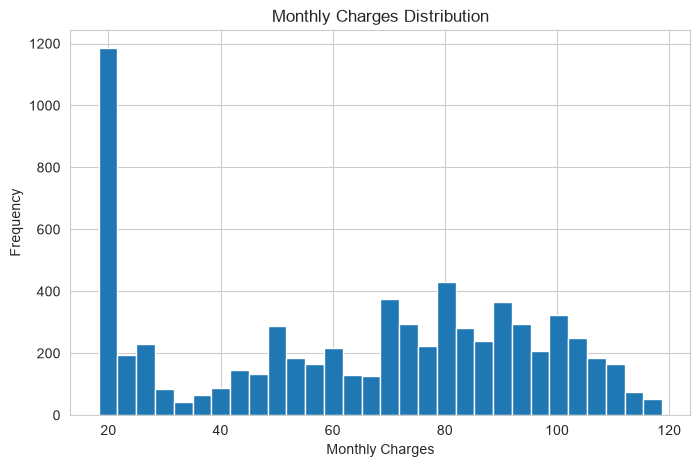

In [44]:
plt.figure(figsize=(8,5))

plt.hist(df["monthlycharges"], bins=30)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.ylabel("Frequency")

plt.savefig("../reports/monthly_charges_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

2️⃣ Bar Chart

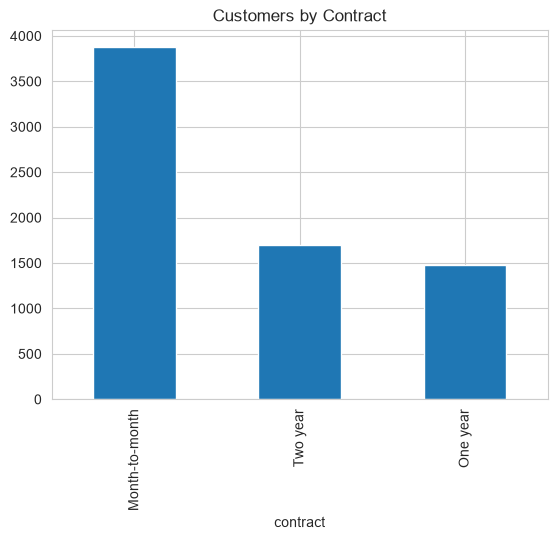

In [45]:
df["contract"].value_counts().plot(kind="bar")

plt.title("Customers by Contract")

plt.savefig("../reports/contract_bar_chart.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

3️⃣ Line Plot

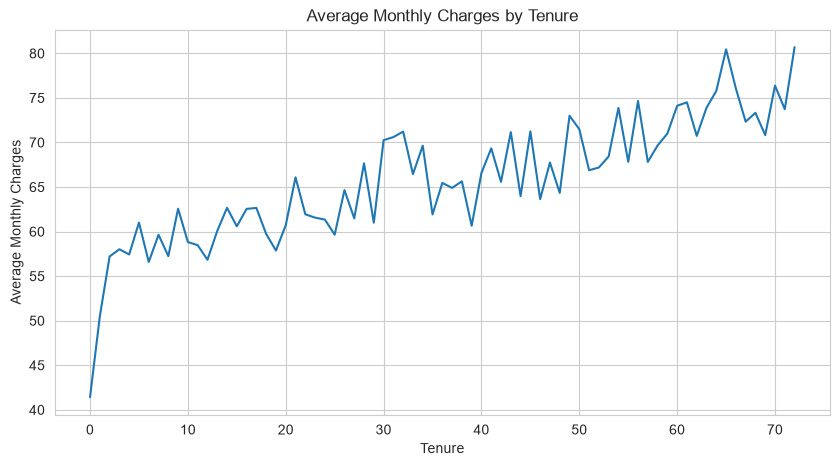

In [46]:
avg_charge = (
    df.groupby("tenure")["monthlycharges"]
      .mean()
)

plt.figure(figsize=(10,5))
plt.plot(avg_charge)
plt.title("Average Monthly Charges by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Average Monthly Charges")

plt.savefig("../reports/tenure_vs_totalcharges.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

4️⃣ Scatter Plot

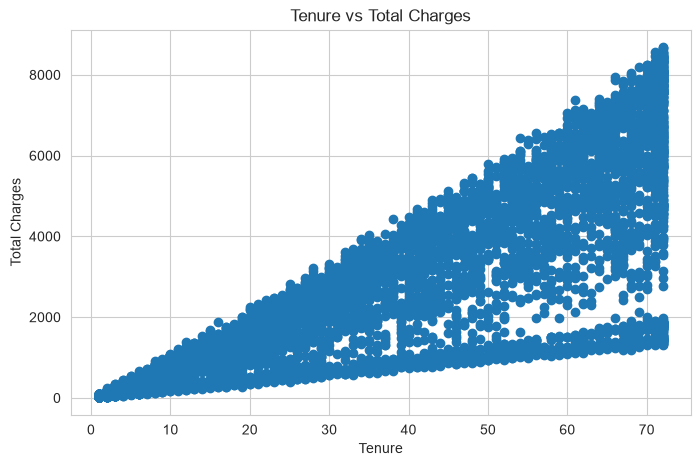

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["tenure"],
    df["totalcharges"]
)

plt.xlabel("Tenure")
plt.ylabel("Total Charges")
plt.title("Tenure vs Total Charges")

plt.show()

subplots

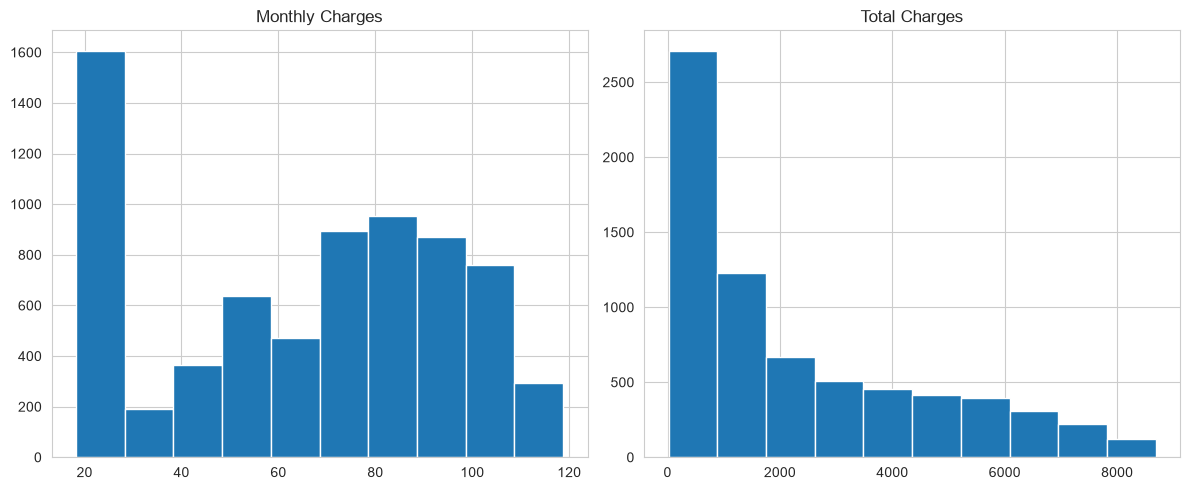

In [36]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].hist(df["monthlycharges"])

ax[0].set_title("Monthly Charges")

ax[1].hist(df["totalcharges"])

ax[1].set_title("Total Charges")

plt.tight_layout()

plt.show()

📈 Seaborn

Heatmap

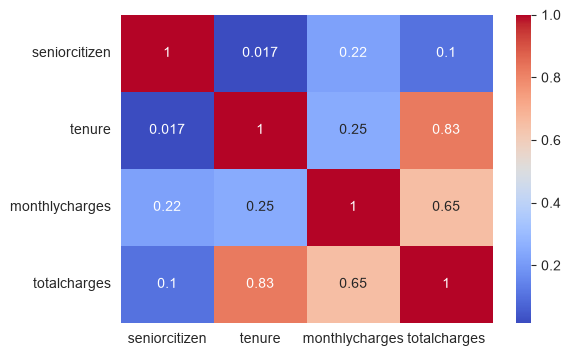

In [47]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.savefig(
    "../reports/heatmap.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

Pairplot

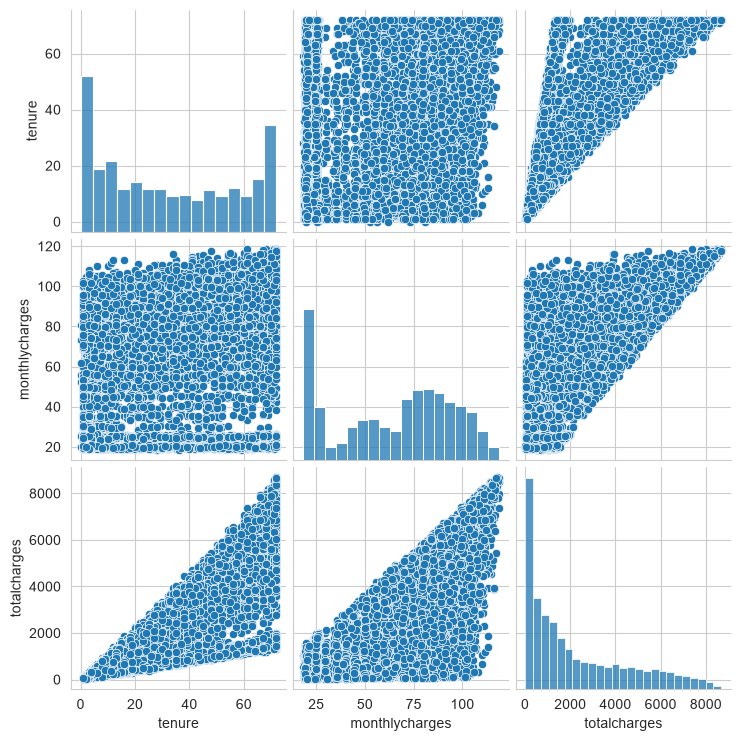

In [48]:
pair=sns.pairplot(
    df[
        [
            "tenure",
            "monthlycharges",
            "totalcharges"
        ]
    ]
)

pair.savefig(
    "../reports/pairplot.png",
    dpi=300)

plt.show()

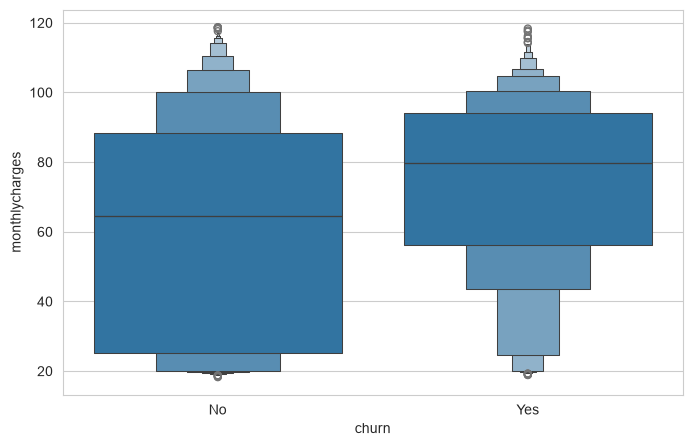

In [49]:
plt.figure(figsize=(8,5))

sns.boxenplot(
    data=df,
    x="churn",
    y="monthlycharges"
)
g.savefig(
    "../reports/facetgrid.png",
    dpi=300)

plt.show()

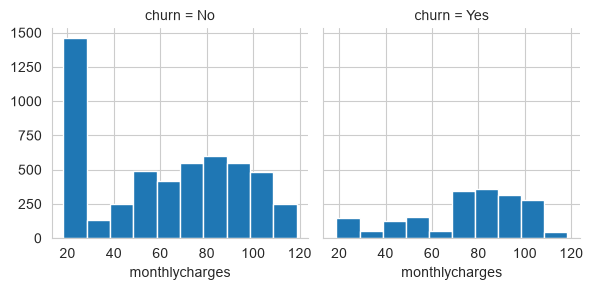

In [40]:
g = sns.FacetGrid(
    df,
    col="churn"
)

g.map(
    plt.hist,
    "monthlycharges"
)

plt.show()

🚀 Plotly

In [41]:
fig = px.bar(
    df,
    x="contract",
    color="churn"
)

fig.show()

In [42]:
fig = px.histogram(
    df,
    x="monthlycharges",
    color="churn"
)

fig.show()